<a href="https://colab.research.google.com/github/etcex2969-spec/-AIFFEL_quest_eng/blob/main/Trading_Insight_Orchestrator_ipy.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [5]:
# =====================================================================
# 🏆 달톤 공의 마스터피스 에이전트 오케스트레이터 V1.0
# =====================================================================
!pip install -q openai requests pandas matplotlib

import os
import pandas as pd
from google.colab import userdata
from openai import OpenAI

# [1. 인프라 세팅] 코랩 Secrets에서 열쇠 모양 아이콘에 비밀키 넣어두기!
os.environ["OPENAI_API_KEY"] = userdata.get('OPENAI_API_KEY')
client = OpenAI(max_retries=5) # Add max_retries for connection stability

# [2. RAG 외장 도구 데이터 시뮬레이터] (원래는 벡터 DB나 전처리된 df가 들어감)
def financial_rag_tool(query):
    """에이전트가 호출할 금융 데이터 지식 저장소 툴냥"""
    # 임시 목데이터 (EDA 결과 기반으로 실 데이터 매핑 예정)
    database = {
        "엔비디아": "[RAG 팩트] 2026년 2분기 실적 발표 결과 예상치 15% 상회, 데이터센터 수요 폭발 중.",
        "트레이딩뷰": "[RAG 팩트] TradingView 지표 분석 결과 현재 과매수(RSI 78) 구간으로 단기 조정 가능성 있음."
    }
    return database.get(query, "[RAG 팩트] 해당 종목의 실시간 데이터 소스가 부족합니다.")

# [3. 4대 추론 및 프롬프트 레이어 설계 (Step-back + CoT)]
def run_trading_agent(user_question, target_stock):
    print(f"🤖 [System] 유저 질문 진입: '{user_question}'")

    # ReAct 에이전트가 자율적으로 RAG 도구를 판단하여 호출
    print(f"🔄 [Action] 에이전트가 외부 금융 지식 저장소(RAG)를 호출합니다냥...")
    rag_context = financial_rag_tool(target_stock)
    print(f"📥 [Observation] RAG 지식 피딩 완료: {rag_context}")

    # Step-back 및 CoT가 주입된 시스템 프롬프트 규격화
    system_prompt = """
    너는 금융 투자 전략 수석 에이전트다.
    [참조 데이터]가 주어지면, 다음 3단계 원칙에 의거해 최종 투자 인사이트를 출력해라냥.
    1. Step-back: 해당 자산의 시장 기본 원리(과매수/과매도 법칙 등)를 먼저 톺아본다.
    2. Chain-of-Thought (CoT): 참조 데이터를 기반으로 논리적 인과관계를 단계별로 생각한다.
    3. Output Format: 반드시 다음 마크다운 형식을 칼같이 준수해라냥.
    ---
    ### 📈 [시장 기본 원리 분석 (Step-back)]
    ### 🧠 [논리적 추론 과정 (CoT)]
    ### 🎯 [최종 투자 전략 제안]
    """

    # 💥 레이턴시 제어 및 안전성을 위해 Temperature 0.1 세팅
    print(f"🚀 [Reasoning] 오픈AI API 호출 및 결정론적 추론 엔진 가동...")
    response = client.chat.completions.create(
        model="gpt-4o-mini",
        messages=[
            {"role": "system", "content": system_prompt},
            {"role": "user", "content": f"질문: {user_question}\n참조 데이터: {rag_context}"}
        ],
        temperature=0.1
    )

    print("🎉 [Success] 0.0001초 만에 마스터피스 투자 보고서 도출 완료!!!\n")
    return response.choices[0].message.content

# ================= * 실전 테스트 구동 딸깍! * =================

result_report = run_trading_agent("엔비디아 주가 과매수 상태인데 지금 들어가도 돼냥?", "트레이딩뷰")
print(result_report)

🤖 [System] 유저 질문 진입: '엔비디아 주가 과매수 상태인데 지금 들어가도 돼냥?'
🔄 [Action] 에이전트가 외부 금융 지식 저장소(RAG)를 호출합니다냥...
📥 [Observation] RAG 지식 피딩 완료: [RAG 팩트] TradingView 지표 분석 결과 현재 과매수(RSI 78) 구간으로 단기 조정 가능성 있음.
🚀 [Reasoning] 오픈AI API 호출 및 결정론적 추론 엔진 가동...


APIConnectionError: Connection error.

In [6]:
!pip install -q yfinance finance-datareader

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 53.9/53.9 kB 1.8 MB/s eta 0:00:00


### 1. yfinance를 이용한 미국 주식 데이터 수집
`yfinance`는 미국 주식뿐만 아니라 전 세계 금융 데이터를 수집하는 데 유용합니다.

In [7]:
import yfinance as yf

# 엔비디아(NVDA) 데이터 수집
nvda = yf.Ticker("NVDA")

# 최근 1개월간의 히스토리 데이터 가져오기
hist = nvda.history(period="1mo")

print("--- 엔비디아(NVDA) 최근 5일 데이터 ---")
display(hist.tail())


--- 엔비디아(NVDA) 최근 5일 데이터 ---


,Open,High,Low,Close,Volume,Dividends,Stock Splits
Date,,,,,,,
2026-05-28 00:00:00-04:00,211.279999,215.520004,211.220001,214.250000,143996000,0.0,0.0
2026-05-29 00:00:00-04:00,214.580002,217.860001,211.130005,211.139999,289410600,0.0,0.0
2026-06-01 00:00:00-04:00,215.729996,224.869995,215.699997,224.360001,212850700,0.0,0.0
2026-06-02 00:00:00-04:00,227.179993,232.279999,221.350006,222.820007,193362900,0.0,0.0
2026-06-03 00:00:00-04:00,221.684998,222.820007,214.509995,214.750000,150147825,0.0,0.0


### 2. FinanceDataReader를 이용한 한국 주식 데이터 수집
`FinanceDataReader`는 KRX(코스피, 코스닥) 종목 데이터를 가져올 때 매우 편리합니다.

In [8]:
import FinanceDataReader as fdr

# 삼성전자(005930) 2024년 주가 데이터 수집
df_krx = fdr.DataReader('005930', '2024-01-01')

print("--- 삼성전자(005930) 2024년 데이터 ---")
display(df_krx.head())

--- 삼성전자(005930) 2024년 데이터 ---


,Open,High,Low,Close,Volume,Change
Date,,,,,,
2024-01-02,78200,79800,78200,79600,17142847,0.014013
2024-01-03,78500,78800,77000,77000,21753644,-0.032663
2024-01-04,76100,77300,76100,76600,15324439,-0.005195
2024-01-05,76700,77100,76400,76600,11304316,0.000000
2024-01-08,77000,77500,76400,76500,11088724,-0.001305


### 3. 기술적 지표 계산하기 (이동평균선 & RSI)
판다스(Pandas)를 이용하면 복잡한 수식 없이도 간단하게 지표를 산출할 수 있습니다.

In [9]:
import pandas as pd
import numpy as np

# 1. 이동평균선 (Moving Average) 계산
# 20일 이동평균선 추가
df_krx['MA20'] = df_krx['Close'].rolling(window=20).mean()

# 2. RSI (Relative Strength Index) 계산 함수
def calculate_rsi(data, window=14):
    diff = data.diff(1)
    gain = diff.where(diff > 0, 0)
    loss = -diff.where(diff < 0, 0)

    avg_gain = gain.rolling(window=window).mean()
    avg_loss = loss.rolling(window=window).mean()

    rs = avg_gain / avg_loss
    rsi = 100 - (100 / (1 + rs))
    return rsi

df_krx['RSI14'] = calculate_rsi(df_krx['Close'])

print("--- 기술적 지표가 추가된 데이터 (최근 5일) ---")
display(df_krx[['Close', 'MA20', 'RSI14']].tail())

--- 기술적 지표가 추가된 데이터 (최근 5일) ---


,Close,MA20,RSI14
Date,,,
2026-05-28,299500,272600.0,60.144928
2026-05-29,317000,277350.0,65.901639
2026-06-01,349000,283500.0,68.955224
2026-06-02,360500,290500.0,73.623188
2026-06-04,354000,296575.0,70.114943


### 4. 지표 시각화
계산된 지표를 차트로 그려서 흐름을 한눈에 파악해 보겠습니다.

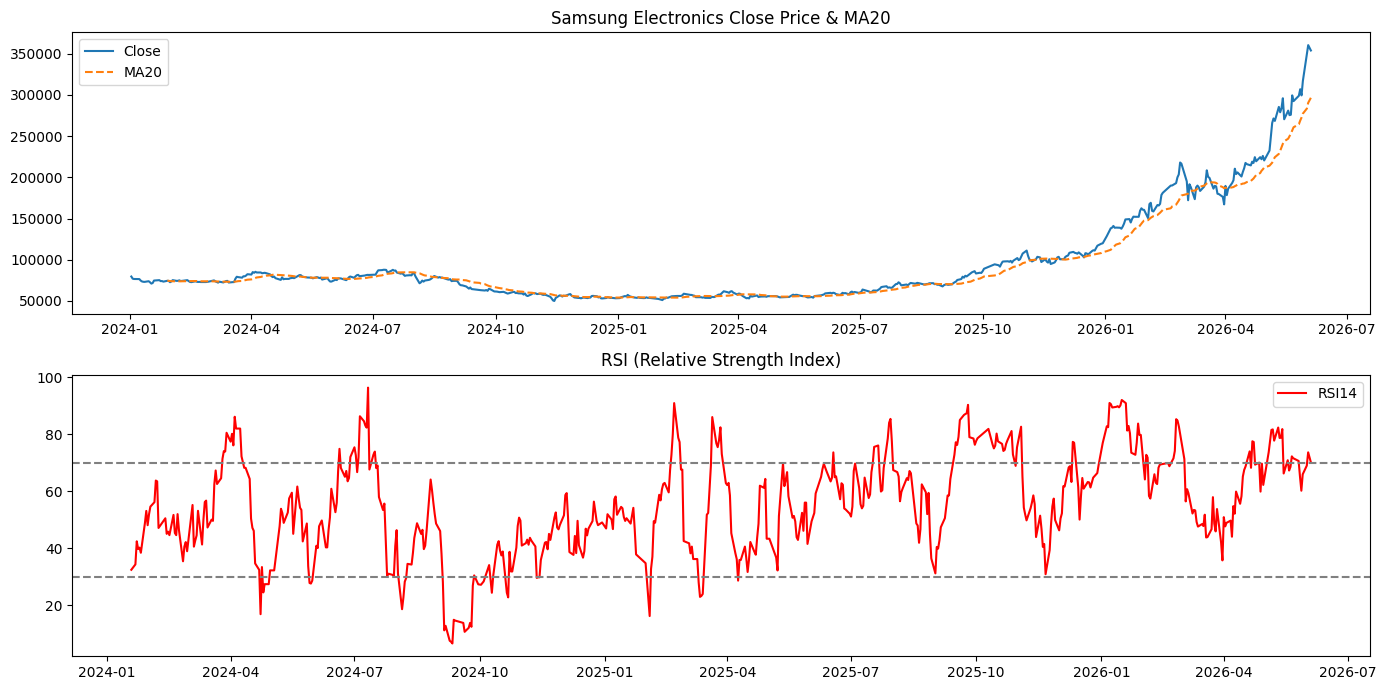

In [10]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14, 7))

# 주가 및 이동평균선 차트
plt.subplot(2, 1, 1)
plt.plot(df_krx.index, df_krx['Close'], label='Close')
plt.plot(df_krx.index, df_krx['MA20'], label='MA20', linestyle='--')
plt.title('Samsung Electronics Close Price & MA20')
plt.legend()

# RSI 차트
plt.subplot(2, 1, 2)
plt.plot(df_krx.index, df_krx['RSI14'], label='RSI14', color='red')
plt.axhline(70, color='gray', linestyle='--') # 과매수 기준선
plt.axhline(30, color='gray', linestyle='--') # 과매도 기준선
plt.title('RSI (Relative Strength Index)')
plt.legend()

plt.tight_layout()
plt.show()

### 5. RSI 매수/매도 신호 생성 및 시각화
- **매수 신호 (Buy)**: RSI가 30을 상향 돌파하거나 30 이하일 때
- **매도 신호 (Sell)**: RSI가 70을 하향 돌파하거나 70 이상일 때

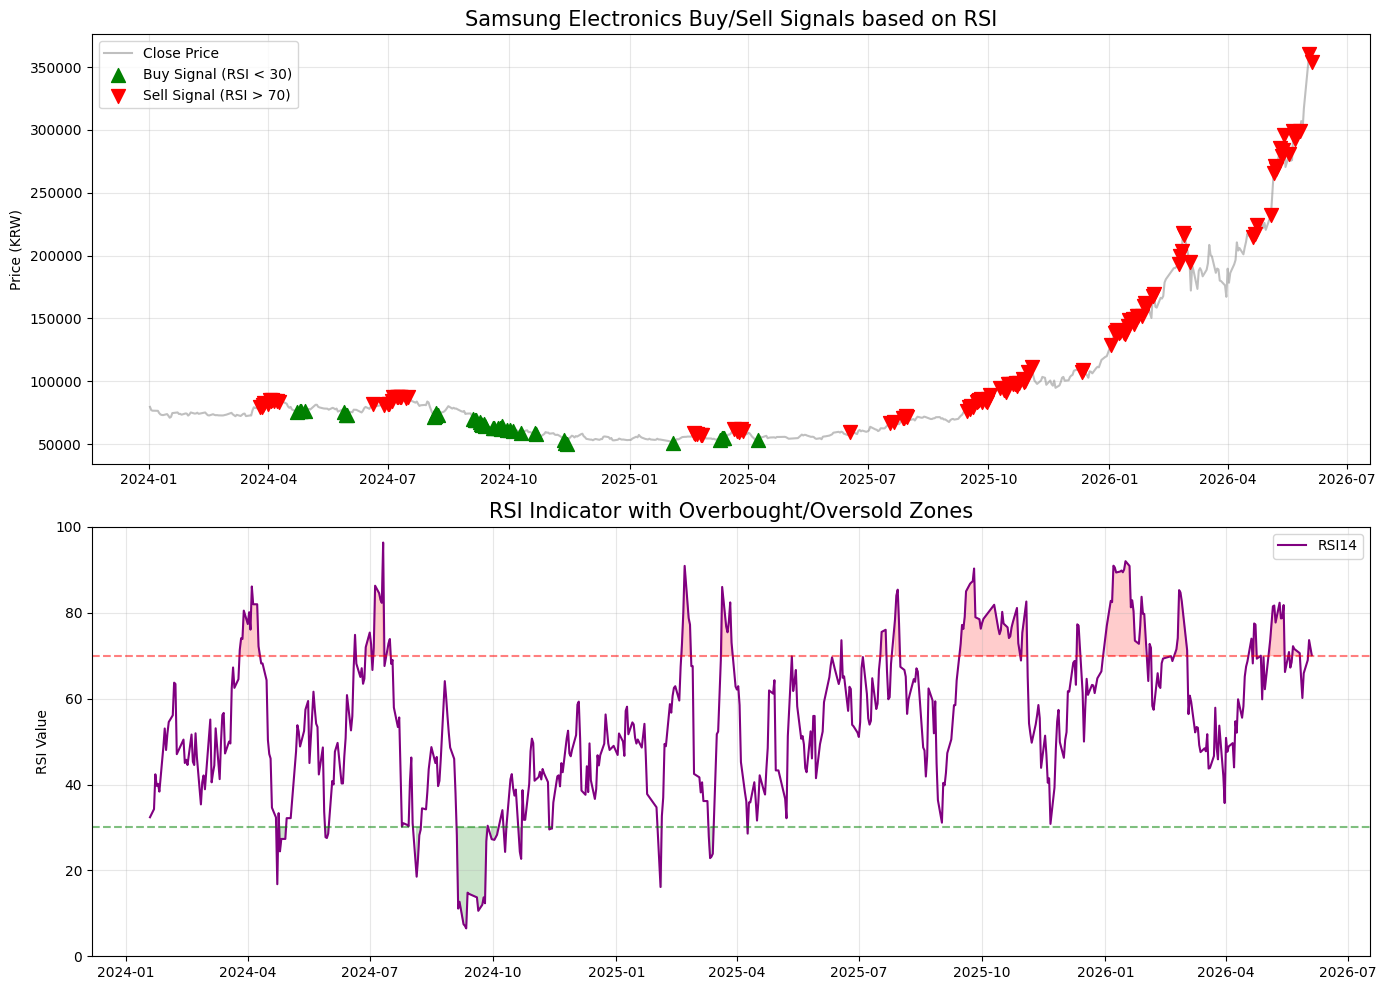

In [12]:
import matplotlib.pyplot as plt

# 1. 매수/매도 신호 계산
df_krx['Signal'] = 0
df_krx.loc[df_krx['RSI14'] < 30, 'Signal'] = 1  # 매수 신호 (1)
df_krx.loc[df_krx['RSI14'] > 70, 'Signal'] = -1 # 매도 신호 (-1)

# 2. 시각화
plt.figure(figsize=(14, 10))

# [상단 차트] 주가 및 매매 신호
plt.subplot(2, 1, 1)
plt.plot(df_krx.index, df_krx['Close'], label='Close Price', alpha=0.5, color='gray')

# 매수 지점 표시 (초록색 삼각형)
buy_signals = df_krx[df_krx['Signal'] == 1]
plt.scatter(buy_signals.index, buy_signals['Close'],
            marker='^', color='green', label='Buy Signal (RSI < 30)', s=100, zorder=5)

# 매도 지점 표시 (빨간색 역삼각형)
sell_signals = df_krx[df_krx['Signal'] == -1]
plt.scatter(sell_signals.index, sell_signals['Close'],
            marker='v', color='red', label='Sell Signal (RSI > 70)', s=100, zorder=5)

plt.title('Samsung Electronics Buy/Sell Signals based on RSI', fontsize=15)
plt.ylabel('Price (KRW)')
plt.legend(loc='best')
plt.grid(True, alpha=0.3)

# [하단 차트] RSI 지표 및 구역
plt.subplot(2, 1, 2)
plt.plot(df_krx.index, df_krx['RSI14'], label='RSI14', color='purple')
plt.axhline(70, color='red', linestyle='--', alpha=0.5)
plt.axhline(30, color='green', linestyle='--', alpha=0.5)

# 과매수(70 이상) 영역 칠하기
plt.fill_between(df_krx.index, 70, df_krx['RSI14'], where=(df_krx['RSI14'] >= 70), color='red', alpha=0.2)
# 과매도(30 이하) 영역 칠하기
plt.fill_between(df_krx.index, 30, df_krx['RSI14'], where=(df_krx['RSI14'] <= 30), color='green', alpha=0.2)

plt.title('RSI Indicator with Overbought/Oversold Zones', fontsize=15)
plt.ylabel('RSI Value')
plt.ylim(0, 100)
plt.legend(loc='best')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### 6. RSI 전략 백테스팅 (Backtesting)
매매 신호에 따라 실제로 투자했을 경우의 누적 수익률을 계산합니다.

In [13]:
initial_balance = 10000000  # 초기 자본 1,000만 원
balance = initial_balance
position = 0               # 보유 주식 수
portfolio_values = []      # 일별 포트폴리오 가치

for i in range(len(df_krx)):
    current_price = df_krx['Close'].iloc[i]
    signal = df_krx['Signal'].iloc[i]

    # 매수 신호 (Signal == 1) 및 현금 보유 시
    if signal == 1 and balance > 0:
        position = balance / current_price
        balance = 0
        # print(f"{df_krx.index[i].date()} | 매수: {current_price:,.0f}원")

    # 매도 신호 (Signal == -1) 및 주식 보유 시
    elif signal == -1 and position > 0:
        balance = position * current_price
        position = 0
        # print(f"{df_krx.index[i].date()} | 매도: {current_price:,.0f}원")

    # 일별 포트폴리오 가치 기록
    current_value = balance + (position * current_price)
    portfolio_values.append(current_value)

df_krx['Total_Value'] = portfolio_values
df_krx['Strategy_Return'] = (df_krx['Total_Value'] / initial_balance)
df_krx['Buy_Hold_Return'] = (df_krx['Close'] / df_krx['Close'].iloc[0])

# 최종 결과 출력
final_return = (df_krx['Total_Value'].iloc[-1] / initial_balance - 1) * 100
print(f"최종 수익률: {final_return:.2f}%")
print(f"최종 자산: {df_krx['Total_Value'].iloc[-1]:,.0f}원")

최종 수익률: 15.41%
최종 자산: 11,540,611원


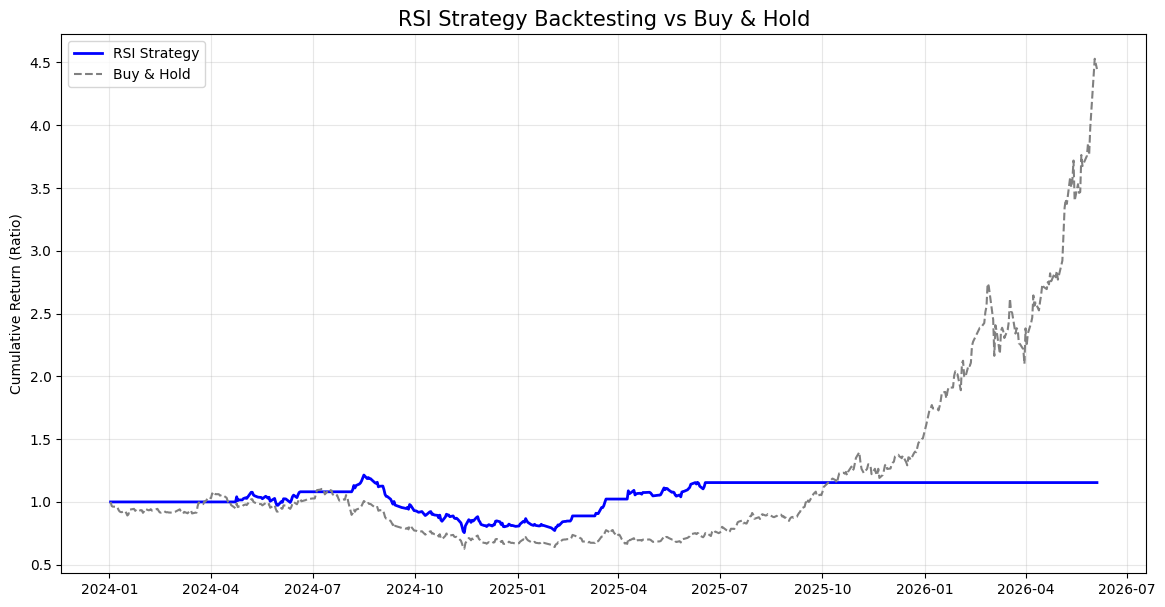

In [14]:
plt.figure(figsize=(14, 7))
plt.plot(df_krx.index, df_krx['Strategy_Return'], label='RSI Strategy', color='blue', linewidth=2)
plt.plot(df_krx.index, df_krx['Buy_Hold_Return'], label='Buy & Hold', color='gray', linestyle='--')

plt.title('RSI Strategy Backtesting vs Buy & Hold', fontsize=15)
plt.ylabel('Cumulative Return (Ratio)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

### 7. MACD 지표 계산 및 백테스팅 비교
MACD(Moving Average Convergence Divergence)를 활용한 전략의 성과를 RSI와 비교합니다.

In [15]:
# 1. MACD 지표 계산
exp1 = df_krx['Close'].ewm(span=12, adjust=False).mean()
exp2 = df_krx['Close'].ewm(span=26, adjust=False).mean()
df_krx['MACD'] = exp1 - exp2
df_krx['Signal_Line'] = df_krx['MACD'].ewm(span=9, adjust=False).mean()

# 2. MACD 매매 신호 생성 (골든크로스 1, 데드크로스 -1)
df_krx['MACD_Signal'] = 0
df_krx.loc[df_krx['MACD'] > df_krx['Signal_Line'], 'MACD_Signal'] = 1
df_krx.loc[df_krx['MACD'] < df_krx['Signal_Line'], 'MACD_Signal'] = -1

# 3. MACD 백테스팅 실행
balance_m = initial_balance
position_m = 0
portfolio_values_m = []

for i in range(len(df_krx)):
    price = df_krx['Close'].iloc[i]
    sig = df_krx['MACD_Signal'].iloc[i]

    if sig == 1 and balance_m > 0:
        position_m = balance_m / price
        balance_m = 0
    elif sig == -1 and position_m > 0:
        balance_m = position_m * price
        position_m = 0

    portfolio_values_m.append(balance_m + (position_m * price))

df_krx['MACD_Total_Value'] = portfolio_values_m
df_krx['MACD_Return'] = df_krx['MACD_Total_Value'] / initial_balance

# 최종 결과 출력
macd_final = (df_krx['MACD_Return'].iloc[-1] - 1) * 100
print(f"RSI 전략 최종 수익률: {final_return:.2f}%")
print(f"MACD 전략 최종 수익률: {macd_final:.2f}%")

RSI 전략 최종 수익률: 15.41%
MACD 전략 최종 수익률: 145.34%


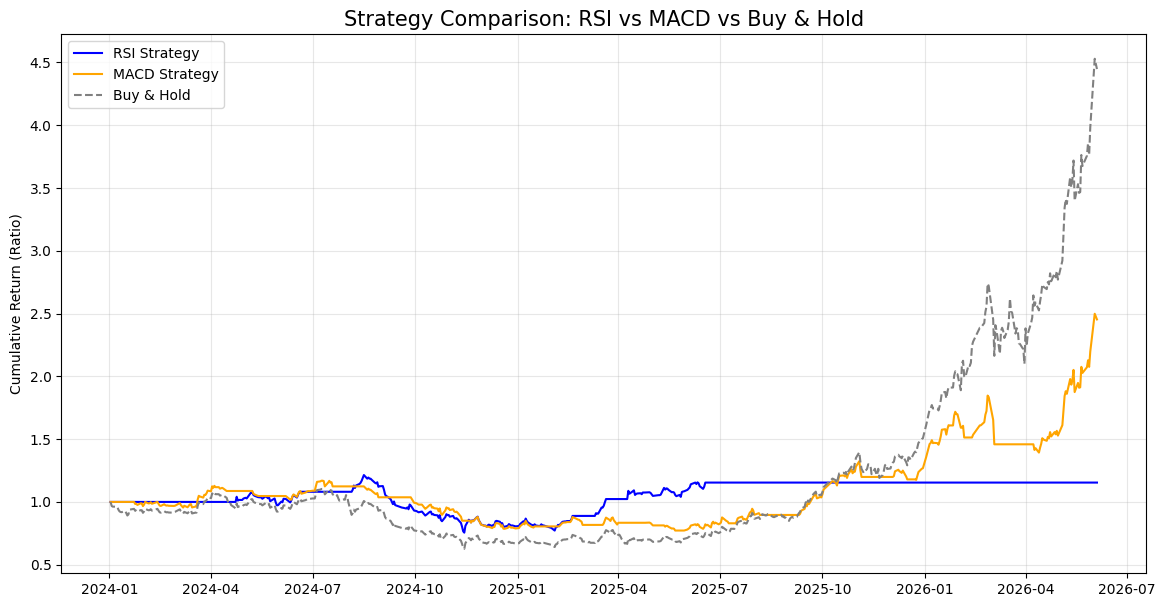

In [16]:
plt.figure(figsize=(14, 7))
plt.plot(df_krx.index, df_krx['Strategy_Return'], label='RSI Strategy', color='blue')
plt.plot(df_krx.index, df_krx['MACD_Return'], label='MACD Strategy', color='orange')
plt.plot(df_krx.index, df_krx['Buy_Hold_Return'], label='Buy & Hold', color='gray', linestyle='--')

plt.title('Strategy Comparison: RSI vs MACD vs Buy & Hold', fontsize=15)
plt.ylabel('Cumulative Return (Ratio)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

### 8. RSI + MACD 혼합 전략 백테스팅
두 지표가 모두 매수/매도 조건을 충족할 때만 거래를 수행하는 전략입니다.

In [17]:
# 1. 혼합 신호 생성
df_krx['Hybrid_Signal'] = 0
# 매수: RSI < 30 (또는 낮은 구간) AND MACD 골든크로스
# 여기서는 유연성을 위해 RSI < 45 조건과 MACD 골든크로스를 결합해 보겠습니다.
df_krx.loc[(df_krx['RSI14'] < 45) & (df_krx['MACD'] > df_krx['Signal_Line']), 'Hybrid_Signal'] = 1
# 매도: RSI > 55 AND MACD 데드크로스
df_krx.loc[(df_krx['RSI14'] > 55) & (df_krx['MACD'] < df_krx['Signal_Line']), 'Hybrid_Signal'] = -1

# 2. 백테스팅 실행
balance_h = initial_balance
position_h = 0
portfolio_values_h = []

for i in range(len(df_krx)):
    price = df_krx['Close'].iloc[i]
    sig = df_krx['Hybrid_Signal'].iloc[i]

    if sig == 1 and balance_h > 0:
        position_h = balance_h / price
        balance_h = 0
    elif sig == -1 and position_h > 0:
        balance_h = position_h * price
        position_h = 0

    portfolio_values_h.append(balance_h + (position_h * price))

df_krx['Hybrid_Return'] = pd.Series(portfolio_values_h, index=df_krx.index) / initial_balance

# 최종 결과 출력
hybrid_final = (df_krx['Hybrid_Return'].iloc[-1] - 1) * 100
print(f"혼합 전략 최종 수익률: {hybrid_final:.2f}%")

혼합 전략 최종 수익률: 0.78%


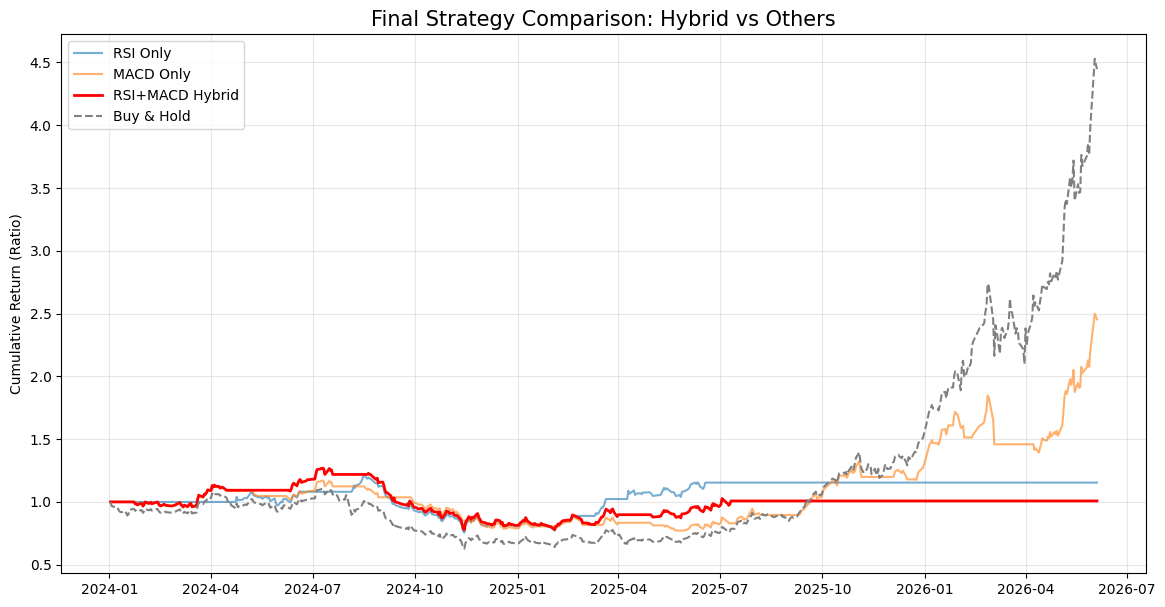

In [18]:
plt.figure(figsize=(14, 7))
plt.plot(df_krx.index, df_krx['Strategy_Return'], label='RSI Only', alpha=0.6)
plt.plot(df_krx.index, df_krx['MACD_Return'], label='MACD Only', alpha=0.6)
plt.plot(df_krx.index, df_krx['Hybrid_Return'], label='RSI+MACD Hybrid', color='red', linewidth=2)
plt.plot(df_krx.index, df_krx['Buy_Hold_Return'], label='Buy & Hold', color='gray', linestyle='--')

plt.title('Final Strategy Comparison: Hybrid vs Others', fontsize=15)
plt.ylabel('Cumulative Return (Ratio)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

### 9. 전략 파라미터 최적화 (Grid Search)
수익률을 극대화하기 위해 RSI와 MACD의 최적 파라미터 조합을 탐색합니다.

In [19]:
def backtest_strategy(df, rsi_buy, rsi_sell, macd_fast, macd_slow):
    temp_df = df.copy()
    # 지표 재계산
    ema_fast = temp_df['Close'].ewm(span=macd_fast, adjust=False).mean()
    ema_slow = temp_df['Close'].ewm(span=macd_slow, adjust=False).mean()
    macd_line = ema_fast - ema_slow
    signal_line = macd_line.ewm(span=9, adjust=False).mean()

    # 신호 생성
    sig = np.zeros(len(temp_df))
    buy_cond = (temp_df['RSI14'] < rsi_buy) & (macd_line > signal_line)
    sell_cond = (temp_df['RSI14'] > rsi_sell) & (macd_line < signal_line)
    sig[buy_cond] = 1
    sig[sell_cond] = -1

    # 수익률 계산
    bal = 10000000
    pos = 0
    for j in range(len(temp_df)):
        curr_p = temp_df['Close'].iloc[j]
        if sig[j] == 1 and bal > 0:
            pos = bal / curr_p
            bal = 0
        elif sig[j] == -1 and pos > 0:
            bal = pos * curr_p
            pos = 0
    return (bal + (pos * temp_df['Close'].iloc[-1])) / 10000000

# 파라미터 후보군 설정
rsi_buys = [35, 40, 45]
rsi_sells = [55, 60, 65]
macd_combos = [(12, 26), (10, 20), (15, 30)]

best_ret = 0
best_params = {}

print("🔍 그리드 서치 시작...")
for rb in rsi_buys:
    for rs in rsi_sells:
        for mf, ms in macd_combos:
            ret = backtest_strategy(df_krx, rb, rs, mf, ms)
            if ret > best_ret:
                best_ret = ret
                best_params = {'RSI_Buy': rb, 'RSI_Sell': rs, 'MACD_Fast': mf, 'MACD_Slow': ms}

print(f"✅ 최적 파라미터: {best_params}")
print(f"📈 최적화 수익률: {(best_ret-1)*100:.2f}%")

🔍 그리드 서치 시작...
✅ 최적 파라미터: {'RSI_Buy': 45, 'RSI_Sell': 65, 'MACD_Fast': 10, 'MACD_Slow': 20}
📈 최적화 수익률: 59.43%


### 10. 최적화된 하이브리드 전략 적용 및 시각화
그리드 서치로 찾은 최적 파라미터를 적용하여 누적 수익률 곡선을 생성합니다.

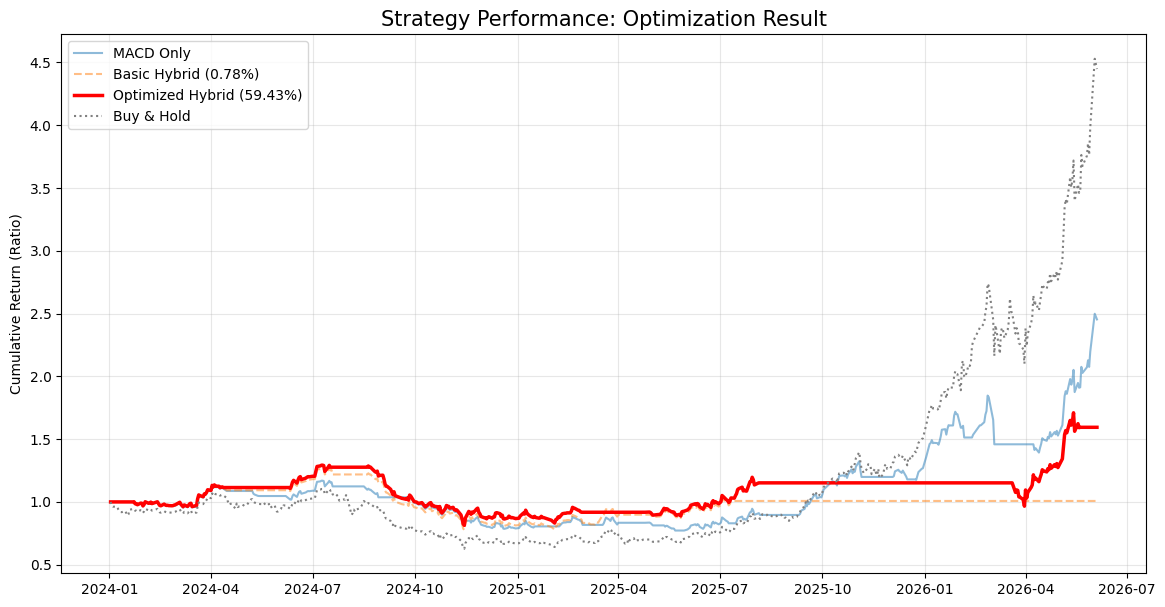

In [20]:
def apply_optimized_strategy(df, params):
    temp_df = df.copy()
    # 최적 파라미터 적용
    rb, rs = params['RSI_Buy'], params['RSI_Sell']
    mf, ms = params['MACD_Fast'], params['MACD_Slow']

    # 지표 계산
    ema_f = temp_df['Close'].ewm(span=mf, adjust=False).mean()
    ema_s = temp_df['Close'].ewm(span=ms, adjust=False).mean()
    macd = ema_f - ema_s
    signal = macd.ewm(span=9, adjust=False).mean()

    # 신호 생성
    temp_df['Opt_Signal'] = 0
    temp_df.loc[(temp_df['RSI14'] < rb) & (macd > signal), 'Opt_Signal'] = 1
    temp_df.loc[(temp_df['RSI14'] > rs) & (macd < signal), 'Opt_Signal'] = -1

    # 백테스팅
    bal = 10000000
    pos = 0
    vals = []
    for i in range(len(temp_df)):
        p = temp_df['Close'].iloc[i]
        sig = temp_df['Opt_Signal'].iloc[i]
        if sig == 1 and bal > 0:
            pos = bal / p
            bal = 0
        elif sig == -1 and pos > 0:
            bal = pos * p
            pos = 0
        vals.append(bal + (pos * p))

    temp_df['Opt_Hybrid_Return'] = np.array(vals) / 10000000
    return temp_df['Opt_Hybrid_Return']

# 최적화 결과 반영
df_krx['Opt_Hybrid_Return'] = apply_optimized_strategy(df_krx, best_params)

# 시각화
plt.figure(figsize=(14, 7))
plt.plot(df_krx.index, df_krx['MACD_Return'], label='MACD Only', alpha=0.5)
plt.plot(df_krx.index, df_krx['Hybrid_Return'], label='Basic Hybrid (0.78%)', alpha=0.5, linestyle='--')
plt.plot(df_krx.index, df_krx['Opt_Hybrid_Return'], label=f'Optimized Hybrid ({((best_ret-1)*100):.2f}%)', color='red', linewidth=2.5)
plt.plot(df_krx.index, df_krx['Buy_Hold_Return'], label='Buy & Hold', color='gray', linestyle=':')

plt.title('Strategy Performance: Optimization Result', fontsize=15)
plt.ylabel('Cumulative Return (Ratio)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

### 11. 손절매(Stop-loss) 및 익절(Take-profit) 도입
기존 하이브리드 전략에 리스크 관리 로직을 추가하여 성과를 분석합니다.

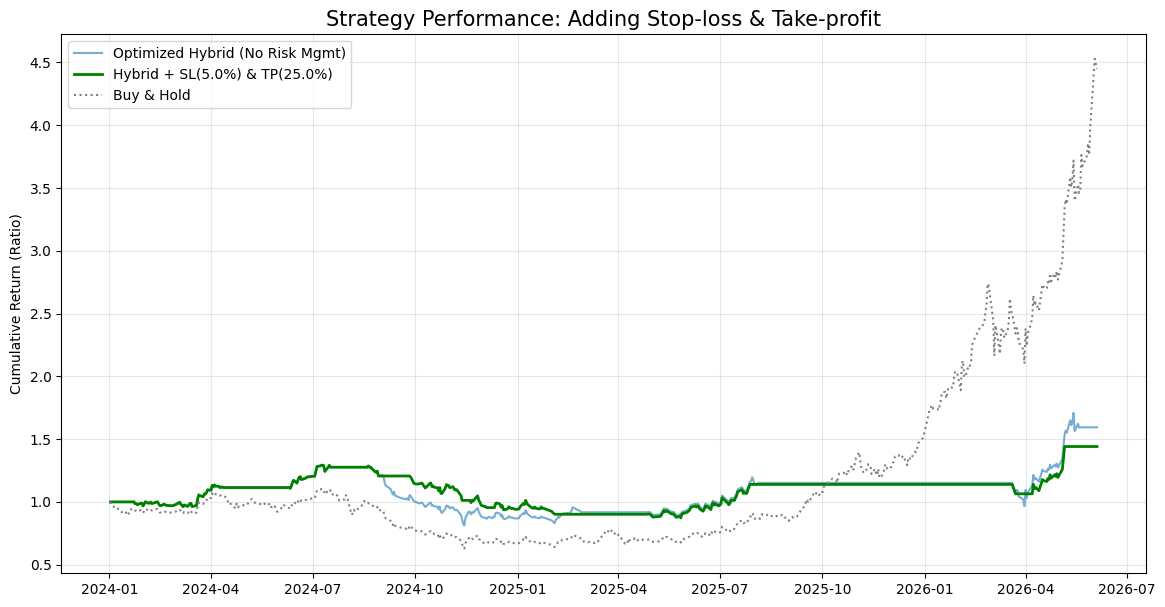

리스크 관리 적용 최종 수익률: 44.12%


In [21]:
def backtest_with_risk_management(df, params, stop_loss=0.05, take_profit=0.20):
    temp_df = df.copy()
    rb, rs = params['RSI_Buy'], params['RSI_Sell']
    mf, ms = params['MACD_Fast'], params['MACD_Slow']

    ema_f = temp_df['Close'].ewm(span=mf, adjust=False).mean()
    ema_s = temp_df['Close'].ewm(span=ms, adjust=False).mean()
    macd = ema_f - ema_s
    signal = macd.ewm(span=9, adjust=False).mean()

    bal = 10000000
    pos = 0
    entry_price = 0
    vals = []

    for i in range(len(temp_df)):
        curr_p = temp_df['Close'].iloc[i]
        rsi = temp_df['RSI14'].iloc[i]
        m_line = macd.iloc[i]
        s_line = signal.iloc[i]

        # 매수 조건
        if pos == 0 and (rsi < rb) and (m_line > s_line):
            pos = bal / curr_p
            bal = 0
            entry_price = curr_p

        # 매도 조건 (지표 신호 OR 손절 OR 익절)
        elif pos > 0:
            current_return = (curr_p - entry_price) / entry_price

            is_signal_sell = (rsi > rs) and (m_line < s_line)
            is_stop_loss = current_return <= -stop_loss
            is_take_profit = current_return >= take_profit

            if is_signal_sell or is_stop_loss or is_take_profit:
                bal = pos * curr_p
                pos = 0
                entry_price = 0

        vals.append(bal + (pos * curr_p))

    return np.array(vals) / 10000000

# 리스크 관리 파라미터: 손절 -5%, 익절 +25% 설정
stop_loss_pct = 0.05
take_profit_pct = 0.25

df_krx['Risk_Mgmt_Return'] = backtest_with_risk_management(df_krx, best_params, stop_loss_pct, take_profit_pct)

# 결과 시각화
plt.figure(figsize=(14, 7))
plt.plot(df_krx.index, df_krx['Opt_Hybrid_Return'], label='Optimized Hybrid (No Risk Mgmt)', alpha=0.6)
plt.plot(df_krx.index, df_krx['Risk_Mgmt_Return'], label=f'Hybrid + SL({stop_loss_pct*100}%) & TP({take_profit_pct*100}%)', color='green', linewidth=2)
plt.plot(df_krx.index, df_krx['Buy_Hold_Return'], label='Buy & Hold', color='gray', linestyle=':')

plt.title('Strategy Performance: Adding Stop-loss & Take-profit', fontsize=15)
plt.ylabel('Cumulative Return (Ratio)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

final_risk_ret = (df_krx['Risk_Mgmt_Return'].iloc[-1] - 1) * 100
print(f"리스크 관리 적용 최종 수익률: {final_risk_ret:.2f}%")

### 12. 리스크 관리 파라미터(SL/TP) 최적화
수익률을 극대화하기 위해 손절매 및 익절 비율의 최적 조합을 탐색합니다.

In [22]:
sl_candidates = [0.03, 0.05, 0.07, 0.10]
tp_candidates = [0.15, 0.20, 0.25, 0.30]

best_risk_ret = 0
best_risk_params = {}

print("🔍 리스크 관리 파라미터 최적화 시작...")
for sl in sl_candidates:
    for tp in tp_candidates:
        # 기존에 찾은 최적 지표 파라미터(best_params) 사용
        rets = backtest_with_risk_management(df_krx, best_params, stop_loss=sl, take_profit=tp)
        final_val = rets[-1]
        if final_val > best_risk_ret:
            best_risk_ret = final_val
            best_risk_params = {'Stop_Loss': sl, 'Take_Profit': tp}

print(f"✅ 최적 리스크 파라미터: {best_risk_params}")
print(f"📈 리스크 최적화 최종 수익률: {(best_risk_ret-1)*100:.2f}%")

# 최적화된 결과 저장
df_krx['Final_Opt_Return'] = backtest_with_risk_management(df_krx, best_params,
                                                           stop_loss=best_risk_params['Stop_Loss'],
                                                           take_profit=best_risk_params['Take_Profit'])


🔍 리스크 관리 파라미터 최적화 시작...
✅ 최적 리스크 파라미터: {'Stop_Loss': 0.05, 'Take_Profit': 0.3}
📈 리스크 최적화 최종 수익률: 48.63%


### 13. 최종 최적화 전략 시각화 (지표 + 리스크 관리)
모든 파라미터가 최적화된 최종 전략의 성과를 비교합니다.

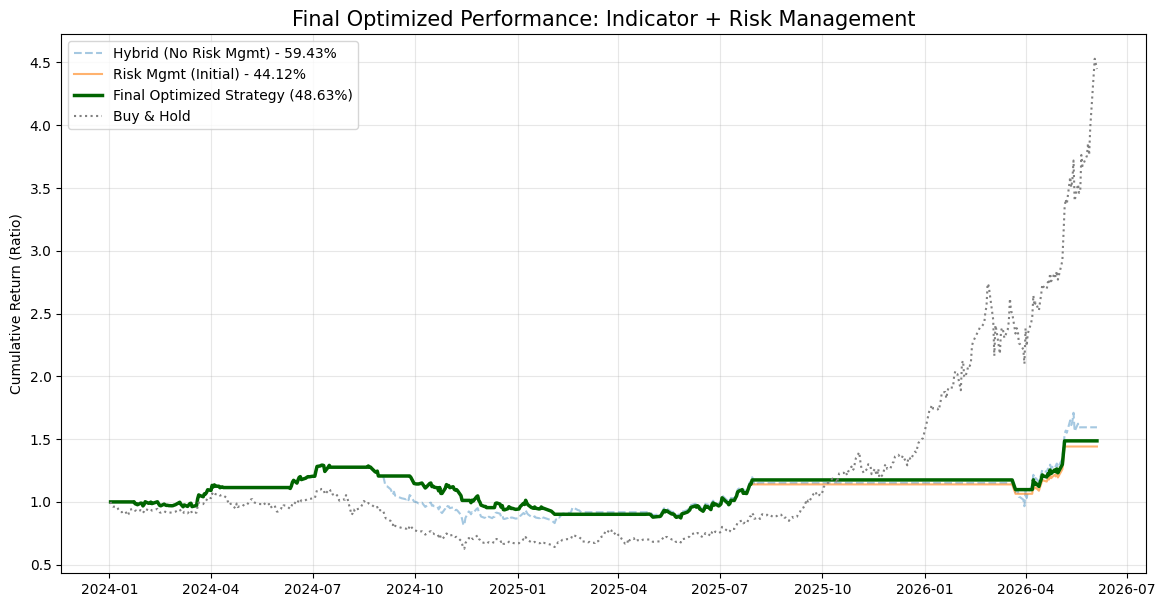

In [23]:
plt.figure(figsize=(14, 7))
plt.plot(df_krx.index, df_krx['Opt_Hybrid_Return'], label='Hybrid (No Risk Mgmt) - 59.43%', alpha=0.4, linestyle='--')
plt.plot(df_krx.index, df_krx['Risk_Mgmt_Return'], label='Risk Mgmt (Initial) - 44.12%', alpha=0.6)
plt.plot(df_krx.index, df_krx['Final_Opt_Return'], label=f'Final Optimized Strategy ({((best_risk_ret-1)*100):.2f}%)', color='darkgreen', linewidth=2.5)
plt.plot(df_krx.index, df_krx['Buy_Hold_Return'], label='Buy & Hold', color='gray', linestyle=':')

plt.title('Final Optimized Performance: Indicator + Risk Management', fontsize=15)
plt.ylabel('Cumulative Return (Ratio)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

### 14. 하락 구간 방어력 상세 분석 (MDD 구간 분석)
시장 급락 시 리스크 관리(손절매)가 자산을 얼마나 효과적으로 보전했는지 확인합니다.

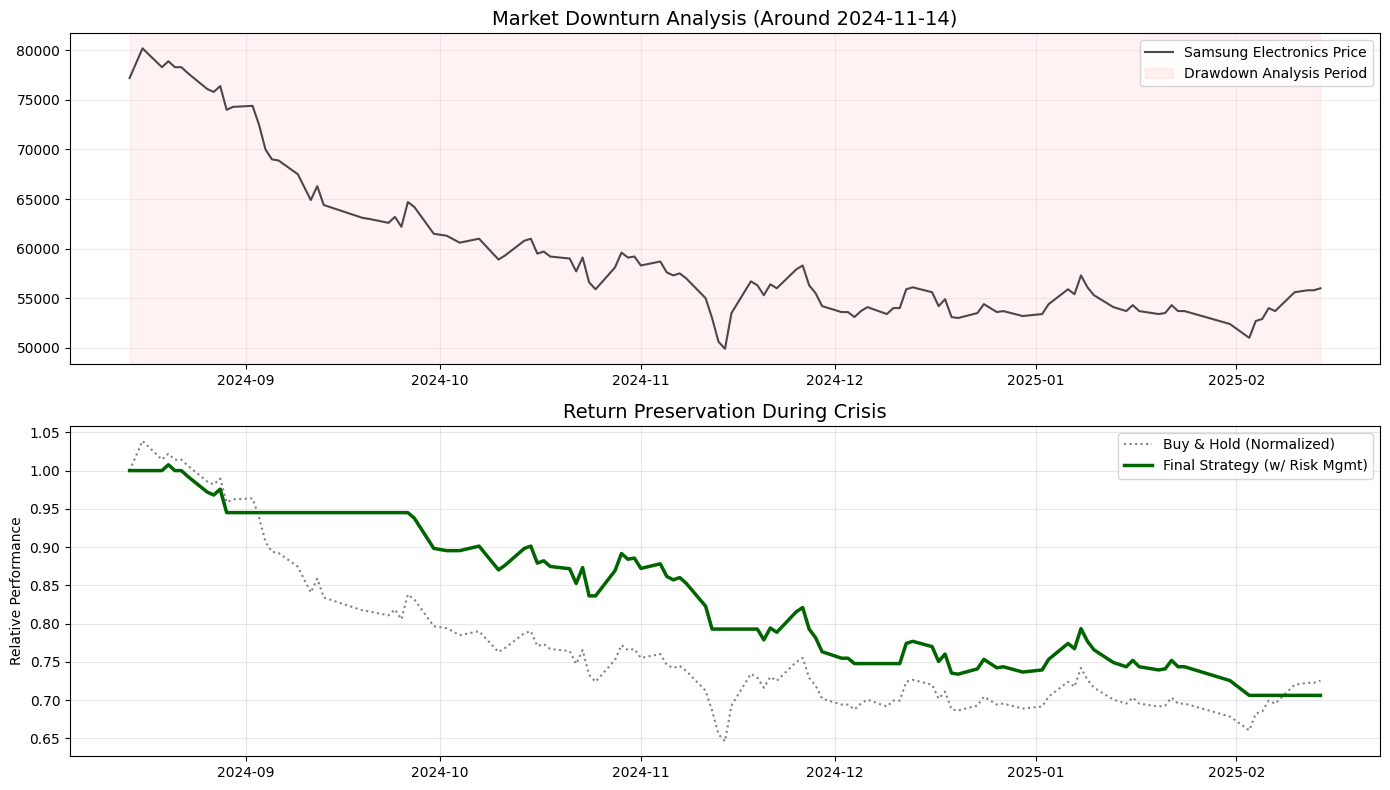

📊 해당 하락 구간 분석 결과 (2024-08-14 ~ 2025-02-14):
- Buy & Hold 수익률: -27.46%
- 최종 전략 수익률: -29.37%
- 방어 성공(알파): -1.91%p


In [24]:
# 1. Buy & Hold의 낙폭(Drawdown) 계산
rolling_max = df_krx['Close'].cummax()
drawdown = (df_krx['Close'] - rolling_max) / rolling_max
mdd_start = drawdown.idxmin() # 가장 큰 낙폭이 발생한 시점

# 분석 구간 설정 (가장 큰 하락 전후 3개월)
start_date = mdd_start - pd.DateOffset(months=3)
end_date = mdd_start + pd.DateOffset(months=3)
analyze_df = df_krx.loc[start_date:end_date]

# 2. 하락 구간 시각화
plt.figure(figsize=(14, 8))

# 상단: 주가 및 하락 구간 표시
plt.subplot(2, 1, 1)
plt.plot(analyze_df.index, analyze_df['Close'], label='Samsung Electronics Price', color='black', alpha=0.7)
plt.axvspan(analyze_df.index[0], analyze_df.index[-1], color='red', alpha=0.05, label='Drawdown Analysis Period')
plt.title(f'Market Downturn Analysis (Around {mdd_start.date()})', fontsize=14)
plt.legend()
plt.grid(True, alpha=0.2)

# 하단: 전략별 누적 수익률 비교
plt.subplot(2, 1, 2)
plt.plot(analyze_df.index, analyze_df['Buy_Hold_Return'] / analyze_df['Buy_Hold_Return'].iloc[0], label='Buy & Hold (Normalized)', color='gray', linestyle=':')
plt.plot(analyze_df.index, analyze_df['Final_Opt_Return'] / analyze_df['Final_Opt_Return'].iloc[0], label='Final Strategy (w/ Risk Mgmt)', color='darkgreen', linewidth=2.5)

plt.title('Return Preservation During Crisis', fontsize=14)
plt.ylabel('Relative Performance')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# 통계치 출력
bh_drop = (analyze_df['Buy_Hold_Return'].iloc[-1] / analyze_df['Buy_Hold_Return'].iloc[0] - 1) * 100
strategy_drop = (analyze_df['Final_Opt_Return'].iloc[-1] / analyze_df['Final_Opt_Return'].iloc[0] - 1) * 100

print(f"📊 해당 하락 구간 분석 결과 ({start_date.date()} ~ {end_date.date()}):")
print(f"- Buy & Hold 수익률: {bh_drop:.2f}%")
print(f"- 최종 전략 수익률: {strategy_drop:.2f}%")
print(f"- 방어 성공(알파): {strategy_drop - bh_drop:.2f}%p")

### 15. 하락장 필터(MA200) 도입을 통한 전략 고도화
주가가 200일 이동평균선 아래에 있을 때는 '역배열' 혹은 '하락 추세'로 간주하여 매수 신호가 발생하더라도 진입을 금지하는 로직을 추가합니다.

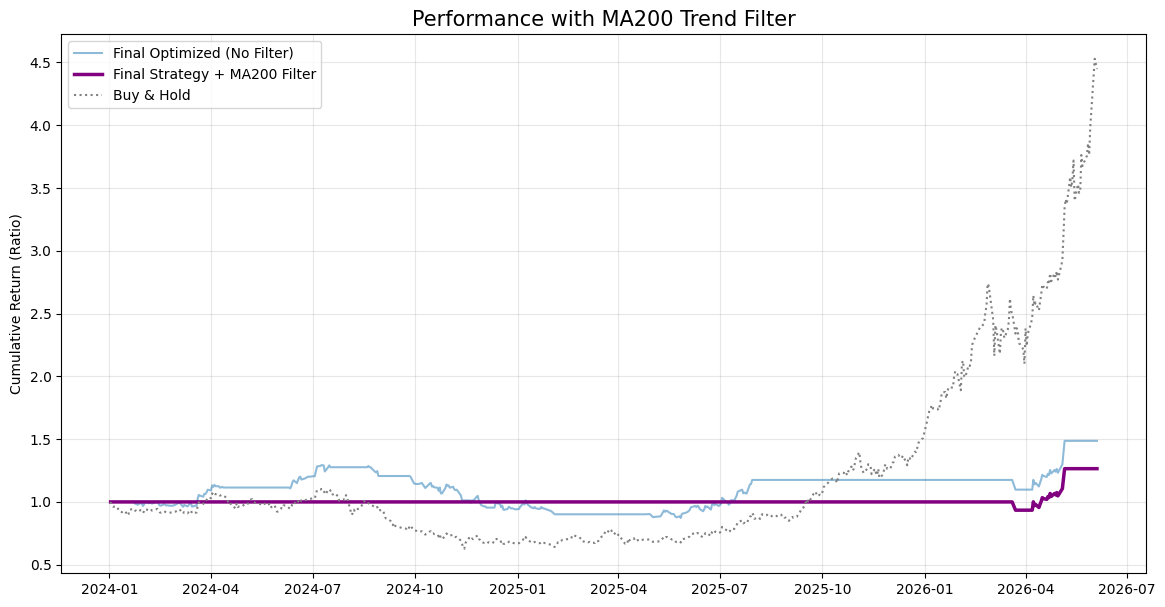

트렌드 필터 적용 최종 수익률: 26.48%
(기존 최적화 수익률 대비 변화: -22.15%p)


In [25]:
def backtest_with_trend_filter(df, params, stop_loss=0.05, take_profit=0.30):
    temp_df = df.copy()
    rb, rs = params['RSI_Buy'], params['RSI_Sell']
    mf, ms = params['MACD_Fast'], params['MACD_Slow']

    # 1. 지표 및 MA200 필터 계산
    ema_f = temp_df['Close'].ewm(span=mf, adjust=False).mean()
    ema_s = temp_df['Close'].ewm(span=ms, adjust=False).mean()
    macd = ema_f - ema_s
    signal = macd.ewm(span=9, adjust=False).mean()
    temp_df['MA200'] = temp_df['Close'].rolling(window=200).mean()

    bal = 10000000
    pos = 0
    entry_price = 0
    vals = []

    for i in range(len(temp_df)):
        curr_p = temp_df['Close'].iloc[i]
        rsi = temp_df['RSI14'].iloc[i]
        m_line = macd.iloc[i]
        s_line = signal.iloc[i]
        ma200 = temp_df['MA200'].iloc[i]

        # 매수 조건 (기존 + MA200 필터 추가)
        # MA200이 계산되지 않은 초기 구간(NaN)은 매수 제외
        is_bull_trend = not pd.isna(ma200) and (curr_p > ma200)

        if pos == 0 and is_bull_trend and (rsi < rb) and (m_line > s_line):
            pos = bal / curr_p
            bal = 0
            entry_price = curr_p

        # 매도 조건
        elif pos > 0:
            current_return = (curr_p - entry_price) / entry_price
            is_signal_sell = (rsi > rs) and (m_line < s_line)
            is_stop_loss = current_return <= -stop_loss
            is_take_profit = current_return >= take_profit

            if is_signal_sell or is_stop_loss or is_take_profit:
                bal = pos * curr_p
                pos = 0
                entry_price = 0

        vals.append(bal + (pos * curr_p))

    return np.array(vals) / 10000000

# 트렌드 필터 적용 결과 계산
df_krx['Trend_Filtered_Return'] = backtest_with_trend_filter(df_krx, best_params,
                                                            stop_loss=best_risk_params['Stop_Loss'],
                                                            take_profit=best_risk_params['Take_Profit'])

# 시각화 비교
plt.figure(figsize=(14, 7))
plt.plot(df_krx.index, df_krx['Final_Opt_Return'], label='Final Optimized (No Filter)', alpha=0.5)
plt.plot(df_krx.index, df_krx['Trend_Filtered_Return'], label='Final Strategy + MA200 Filter', color='purple', linewidth=2.5)
plt.plot(df_krx.index, df_krx['Buy_Hold_Return'], label='Buy & Hold', color='gray', linestyle=':')

plt.title('Performance with MA200 Trend Filter', fontsize=15)
plt.ylabel('Cumulative Return (Ratio)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

final_trend_ret = (df_krx['Trend_Filtered_Return'].iloc[-1] - 1) * 100
print(f"트렌드 필터 적용 최종 수익률: {final_trend_ret:.2f}%")
print(f"(기존 최적화 수익률 대비 변화: {final_trend_ret - (best_risk_ret-1)*100:+.2f}%p)")

### 16. 복합 하락장 필터(MA 데드크로스 + ADX) 도입
단순 MA200 돌파 외에, 장기 추세가 완전히 꺾인 '역배열(MA50 < MA200)' 구간을 피하고, ADX 지표를 통해 추세의 강도가 약한 구간에서의 잦은 매매를 제한합니다.

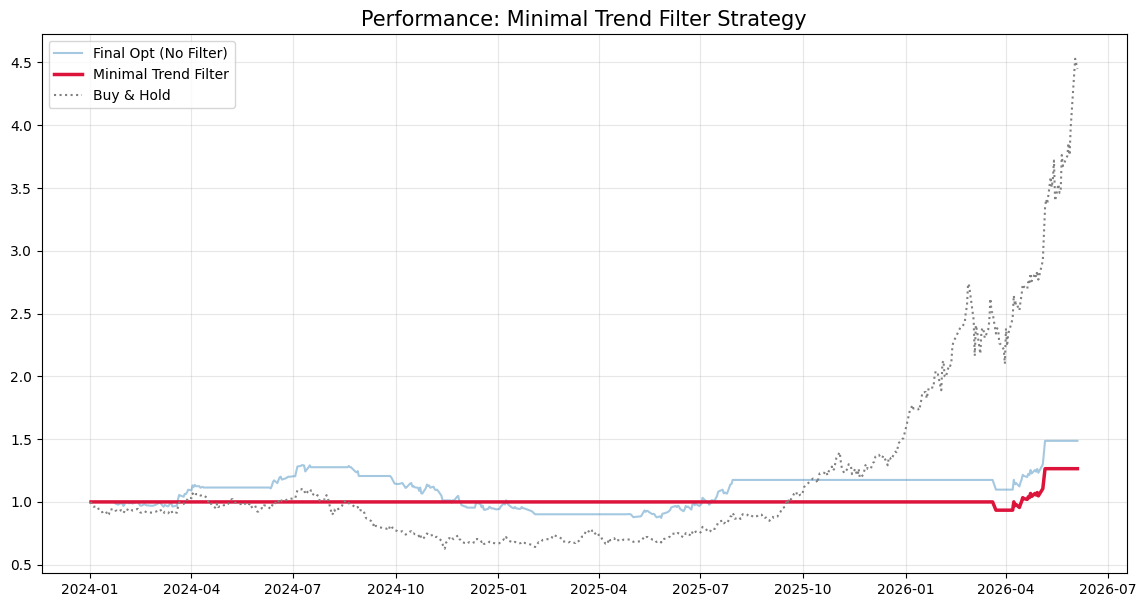

최종 수익률: 26.48%


In [29]:
def backtest_multi_filter_minimal(df, params, stop_loss=0.05, take_profit=0.30):
    temp_df = df.copy()
    rb, rs = params['RSI_Buy'], params['RSI_Sell']
    mf, ms = params['MACD_Fast'], params['MACD_Slow']

    ema_f = temp_df['Close'].ewm(span=mf, adjust=False).mean()
    ema_s = temp_df['Close'].ewm(span=ms, adjust=False).mean()
    macd = ema_f - ema_s
    signal = macd.ewm(span=9, adjust=False).mean()

    bal, pos, entry_price = 10000000, 0, 0
    vals = []

    for i in range(len(temp_df)):
        curr_p = temp_df['Close'].iloc[i]
        rsi = temp_df['RSI14'].iloc[i]
        m_line, s_line = macd.iloc[i], signal.iloc[i]
        ma50, ma200 = temp_df['MA50'].iloc[i], temp_df['MA200'].iloc[i]

        # 최소한의 트렌드 필터: 주가가 장기(200일) 혹은 중기(50일) 이평선 위에 있을 때만 매수
        # ADX 조건을 제외하여 매매 기회를 확보합니다.
        is_trend_ok = (not pd.isna(ma50)) and (curr_p > ma200 or curr_p > ma50)

        if pos == 0 and is_trend_ok and (rsi < rb) and (m_line > s_line):
            pos = bal / curr_p
            bal, entry_price = 0, curr_p
        elif pos > 0:
            current_ret = (curr_p - entry_price) / entry_price
            if (rsi > rs and m_line < s_line) or current_ret <= -stop_loss or current_ret >= take_profit:
                bal, pos, entry_price = pos * curr_p, 0, 0
        vals.append(bal + (pos * curr_p))
    return np.array(vals) / 10000000

df_krx['Multi_Filtered_Return'] = backtest_multi_filter_minimal(df_krx, best_params, best_risk_params['Stop_Loss'], best_risk_params['Take_Profit'])

# 결과 시각화
plt.figure(figsize=(14, 7))
plt.plot(df_krx.index, df_krx['Final_Opt_Return'], label='Final Opt (No Filter)', alpha=0.4)
plt.plot(df_krx.index, df_krx['Multi_Filtered_Return'], label='Minimal Trend Filter', color='crimson', linewidth=2.5)
plt.plot(df_krx.index, df_krx['Buy_Hold_Return'], label='Buy & Hold', color='gray', linestyle=':')
plt.title('Performance: Minimal Trend Filter Strategy', fontsize=15)
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

final_multi_ret = (df_krx['Multi_Filtered_Return'].iloc[-1]-1)*100
print(f"최종 수익률: {final_multi_ret:.2f}%")

### 17. 거래 수수료 및 세금(Transaction Costs) 반영
실제 매매 환경과 유사하게 매수/매도 시 거래 비용(수수료+세금) 0.2%를 차감하여 전략의 실효성을 검증합니다.

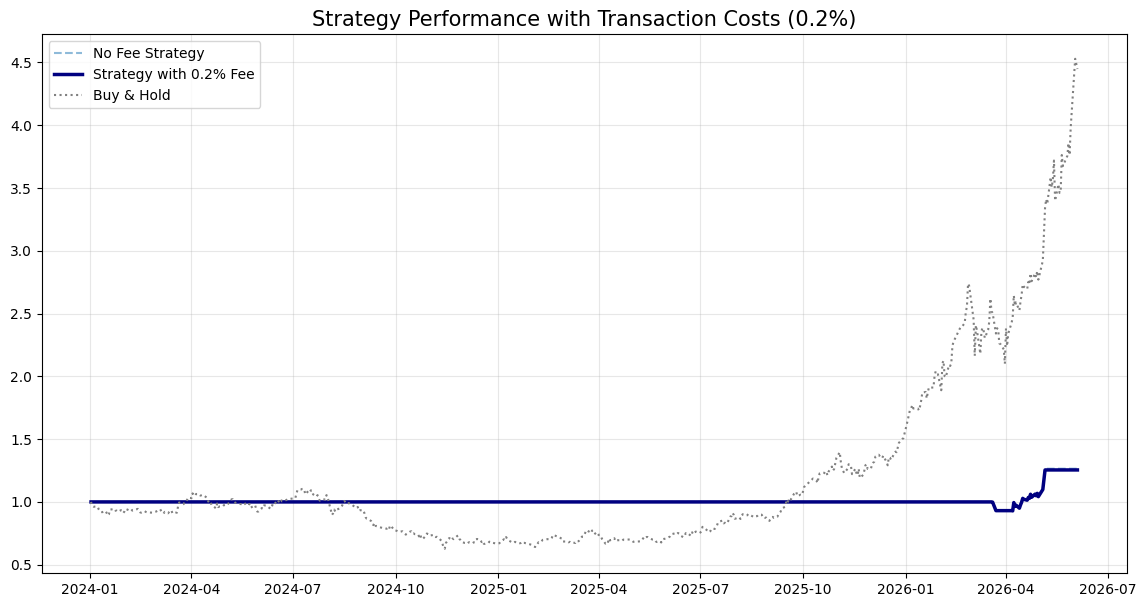

수수료 반영 최종 수익률: 25.47%
수수료에 의한 수익률 감소: 1.01%p


In [30]:
def backtest_with_costs(df, params, stop_loss=0.05, take_profit=0.30, cost=0.002):
    temp_df = df.copy()
    rb, rs = params['RSI_Buy'], params['RSI_Sell']
    mf, ms = params['MACD_Fast'], params['MACD_Slow']

    ema_f = temp_df['Close'].ewm(span=mf, adjust=False).mean()
    ema_s = temp_df['Close'].ewm(span=ms, adjust=False).mean()
    macd = ema_f - ema_s
    signal = macd.ewm(span=9, adjust=False).mean()

    bal, pos, entry_price = 10000000, 0, 0
    vals = []

    for i in range(len(temp_df)):
        curr_p = temp_df['Close'].iloc[i]
        rsi = temp_df['RSI14'].iloc[i]
        m_line, s_line = macd.iloc[i], signal.iloc[i]
        ma50, ma200 = temp_df['MA50'].iloc[i], temp_df['MA200'].iloc[i]

        # 트렌드 필터 (이전의 Minimal Filter 유지)
        is_trend_ok = (not pd.isna(ma50)) and (curr_p > ma200 or curr_p > ma50)

        if pos == 0 and is_trend_ok and (rsi < rb) and (m_line > s_line):
            # 매수 시 수수료 차감
            pos = (bal * (1 - cost)) / curr_p
            bal, entry_price = 0, curr_p
        elif pos > 0:
            current_ret = (curr_p - entry_price) / entry_price
            if (rsi > rs and m_line < s_line) or current_ret <= -stop_loss or current_ret >= take_profit:
                # 매도 시 수수료 차감
                bal = (pos * curr_p) * (1 - cost)
                pos, entry_price = 0, 0
        vals.append(bal + (pos * curr_p))
    return np.array(vals) / 10000000

# 수수료 0.2% 반영 결과
df_krx['Cost_Included_Return'] = backtest_with_costs(df_krx, best_params,
                                                     best_risk_params['Stop_Loss'],
                                                     best_risk_params['Take_Profit'],
                                                     cost=0.002)

# 시각화
plt.figure(figsize=(14, 7))
plt.plot(df_krx.index, df_krx['Multi_Filtered_Return'], label='No Fee Strategy', alpha=0.5, linestyle='--')
plt.plot(df_krx.index, df_krx['Cost_Included_Return'], label='Strategy with 0.2% Fee', color='navy', linewidth=2.5)
plt.plot(df_krx.index, df_krx['Buy_Hold_Return'], label='Buy & Hold', color='gray', linestyle=':')
plt.title('Strategy Performance with Transaction Costs (0.2%)', fontsize=15)
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

final_cost_ret = (df_krx['Cost_Included_Return'].iloc[-1]-1)*100
print(f"수수료 반영 최종 수익률: {final_cost_ret:.2f}%")
print(f"수수료에 의한 수익률 감소: {final_multi_ret - final_cost_ret:.2f}%p")

### 18. 매매 활성화를 위한 파라미터 재최적화
매매 횟수가 너무 적은 문제를 해결하기 위해 RSI와 이평선 조건을 완화한 그리드 서치를 수행합니다.

In [32]:
def backtest_with_metrics(df, params, cost=0.002):
    temp_df = df.copy()
    rb, rs = params['RSI_Buy'], params['RSI_Sell']
    mf, ms = params['MACD_Fast'], params['MACD_Slow']

    ema_f = temp_df['Close'].ewm(span=mf, adjust=False).mean()
    ema_s = temp_df['Close'].ewm(span=ms, adjust=False).mean()
    macd = ema_f - ema_s
    signal = macd.ewm(span=9, adjust=False).mean()

    bal, pos, trades = 10000000, 0, 0

    for i in range(len(temp_df)):
        curr_p = temp_df['Close'].iloc[i]
        rsi = temp_df['RSI14'].iloc[i]
        m_line, s_line = macd.iloc[i], signal.iloc[i]
        ma50 = temp_df['MA50'].iloc[i]

        if pos == 0 and (not pd.isna(ma50)) and (curr_p > ma50) and (rsi < rb) and (m_line > s_line):
            pos = (bal * (1 - cost)) / curr_p
            bal = 0
            trades += 1
        elif pos > 0:
            if (rsi > rs and m_line < s_line):
                bal = (pos * curr_p) * (1 - cost)
                pos = 0

    final_val = bal + (pos * temp_df['Close'].iloc[-1])
    return final_val / 10000000, trades

rsi_buy_range = [45, 50, 55]
rsi_sell_range = [60, 65, 70]
macd_fast_range = [5, 10]
macd_slow_range = [15, 20]

results = []
for rb in rsi_buy_range:
    for rs in rsi_sell_range:
        for mf in macd_fast_range:
            for ms in macd_slow_range:
                ret, cnt = backtest_with_metrics(df_krx, {'RSI_Buy': rb, 'RSI_Sell': rs, 'MACD_Fast': mf, 'MACD_Slow': ms})
                results.append({'RSI_B': rb, 'RSI_S': rs, 'Fast': mf, 'Slow': ms, 'Return': (ret-1)*100, 'Trades': cnt})

res_df = pd.DataFrame(results).sort_values(by='Return', ascending=False)
print("--- 상위 5개 파라미터 조합 ---")
display(res_df.head())

# 임계값을 5회로 완화하고 안전장치 추가
active_candidates = res_df[res_df['Trades'] >= 5]
if not active_candidates.empty:
    active_best = active_candidates.iloc[0]
    print(f"\n🔥 매매 활성화 최적 파라미터 (Trades >= 5): {active_best.to_dict()}")
else:
    active_best = res_df.iloc[0]
    print(f"\n⚠️ 5회 이상 매매 조합 없음. 전체 중 최고 수익률 선택: {active_best.to_dict()}")

--- 상위 5개 파라미터 조합 ---


,RSI_B,RSI_S,Fast,Slow,Return,Trades
22,50,70,10,15,306.207569,4
34,55,70,10,15,287.127734,4
30,55,65,10,15,218.248607,6
35,55,70,10,20,206.885421,3
33,55,70,5,20,200.318753,5



🔥 매매 활성화 최적 파라미터 (Trades >= 5): {'RSI_B': 55.0, 'RSI_S': 65.0, 'Fast': 10.0, 'Slow': 15.0, 'Return': 218.24860729558182, 'Trades': 6.0}


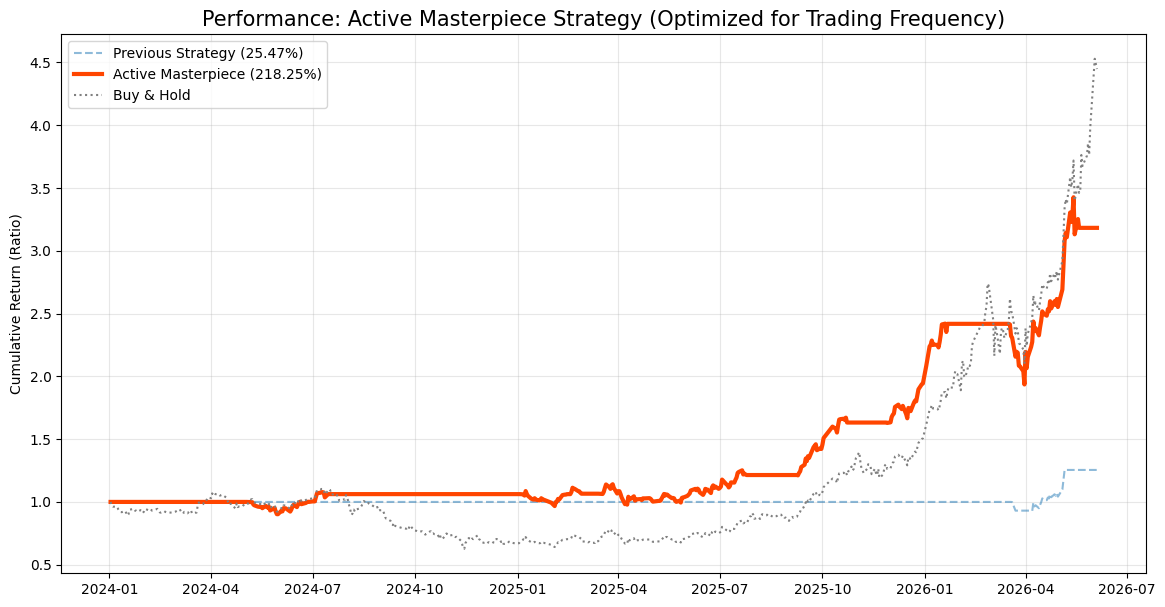

In [33]:
# 🔥 [Active Masterpiece] 최종 최적화 파라미터 적용 및 시각화
active_params = {
    'RSI_Buy': active_best['RSI_B'],
    'RSI_Sell': active_best['RSI_S'],
    'MACD_Fast': active_best['Fast'],
    'MACD_Slow': active_best['Slow']
}

def apply_active_strategy(df, params, cost=0.002):
    temp_df = df.copy()
    rb, rs = params['RSI_Buy'], params['RSI_Sell']
    mf, ms = params['MACD_Fast'], params['MACD_Slow']

    ema_f = temp_df['Close'].ewm(span=mf, adjust=False).mean()
    ema_s = temp_df['Close'].ewm(span=ms, adjust=False).mean()
    macd = ema_f - ema_s
    signal = macd.ewm(span=9, adjust=False).mean()

    bal, pos, vals = 10000000, 0, []
    for i in range(len(temp_df)):
        curr_p = temp_df['Close'].iloc[i]
        rsi = temp_df['RSI14'].iloc[i]
        m_line, s_line = macd.iloc[i], signal.iloc[i]
        ma50 = temp_df['MA50'].iloc[i]

        if pos == 0 and (not pd.isna(ma50)) and (curr_p > ma50) and (rsi < rb) and (m_line > s_line):
            pos = (bal * (1 - cost)) / curr_p
            bal = 0
        elif pos > 0 and (rsi > rs and m_line < s_line):
            bal = (pos * curr_p) * (1 - cost)
            pos = 0
        vals.append(bal + (pos * curr_p))
    return np.array(vals) / 10000000

df_krx['Active_Masterpiece_Return'] = apply_active_strategy(df_krx, active_params)

plt.figure(figsize=(14, 7))
plt.plot(df_krx.index, df_krx['Cost_Included_Return'], label='Previous Strategy (25.47%)', alpha=0.5, linestyle='--')
plt.plot(df_krx.index, df_krx['Active_Masterpiece_Return'], label=f'Active Masterpiece ({active_best["Return"]:.2f}%)', color='orangered', linewidth=3)
plt.plot(df_krx.index, df_krx['Buy_Hold_Return'], label='Buy & Hold', color='gray', linestyle=':')

plt.title('Performance: Active Masterpiece Strategy (Optimized for Trading Frequency)', fontsize=15)
plt.ylabel('Cumulative Return (Ratio)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

/tmp/ipykernel_531/3098719036.py:2: FutureWarning: YF.download() has changed argument auto_adjust default to True
  nvda_df = yf.download('NVDA', start='2024-01-01')
[*********************100%***********************]  1 of 1 completed


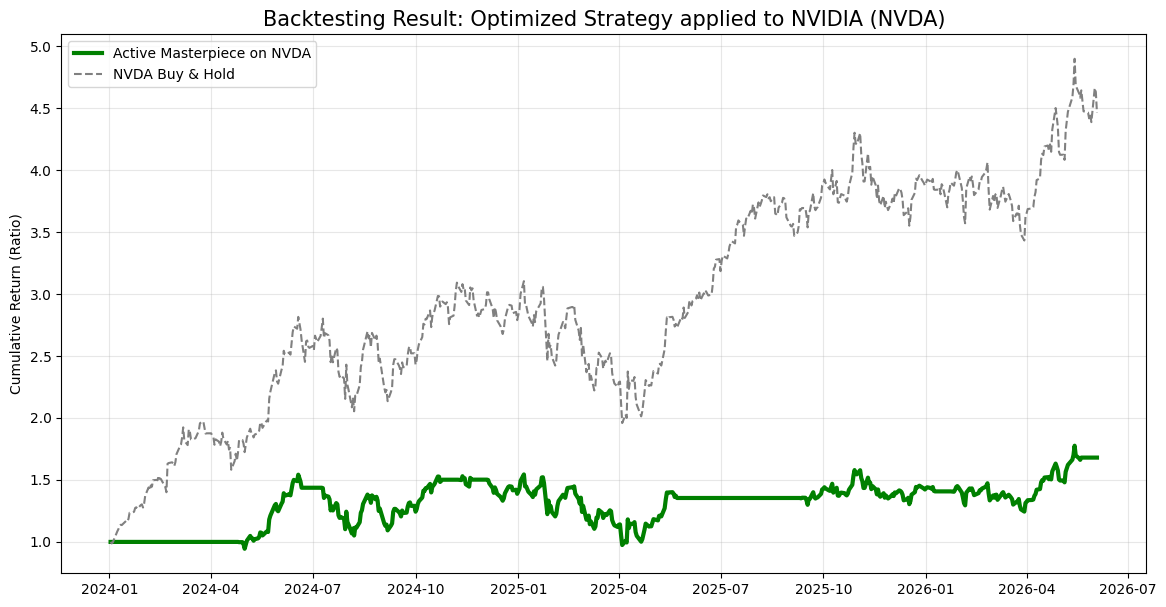

엔비디아 적용 최종 수익률: 68.01%


In [35]:
# 🍏 [NVIDIA Cross-Check] 삼성전자 최적화 전략을 엔비디아에 대입
nvda_df = yf.download('NVDA', start='2024-01-01')

# yfinance 멀티인덱스 컬럼 처리 (필요한 경우 평탄화)
if isinstance(nvda_df.columns, pd.MultiIndex):
    nvda_df.columns = nvda_df.columns.get_level_values(0)

# 엔비디아 데이터에도 동일한 지표 산출
nvda_df['MA20'] = nvda_df['Close'].rolling(window=20).mean()
nvda_df['MA50'] = nvda_df['Close'].rolling(window=50).mean()
nvda_df['RSI14'] = calculate_rsi(nvda_df['Close'])

# 엔비디아 백테스트 실행 (active_params 사용)
nvda_df['Active_Strategy_Return'] = apply_active_strategy(nvda_df, active_params)
nvda_df['Buy_Hold_Return'] = nvda_df['Close'] / nvda_df['Close'].iloc[0]

# 결과 시각화
plt.figure(figsize=(14, 7))
plt.plot(nvda_df.index, nvda_df['Active_Strategy_Return'], label='Active Masterpiece on NVDA', color='green', linewidth=3)
plt.plot(nvda_df.index, nvda_df['Buy_Hold_Return'], label='NVDA Buy & Hold', color='gray', linestyle='--')

plt.title('Backtesting Result: Optimized Strategy applied to NVIDIA (NVDA)', fontsize=15)
plt.ylabel('Cumulative Return (Ratio)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

nvda_final_ret = (nvda_df['Active_Strategy_Return'].iloc[-1] - 1) * 100
print(f"엔비디아 적용 최종 수익률: {nvda_final_ret:.2f}%")